# Loki usage -- tenants / streams / ingest / chunk & query load

Who is spending the ingest and stream budget, and how it trends: streams and
ingest per tenant, discards by reason, chunk-flush health (age/size/entries/
compression), and query load. Health of the system itself:
[loki-health.ipynb](loki-health.ipynb); when Loki can't answer at all:
[loki-nolgtm.ipynb](loki-nolgtm.ipynb).

Loki does **not** export effective per-tenant limits as metrics, so stream/rate
ceilings are config (`loki-values.yaml` `limits_config`, plus any runtime
overrides), not read live here; this notebook reports consumption and flags
limit-shaped discards. Design: [tiles#644](https://github.com/symmatree/tiles/issues/644),
[docs/notebooks.md](../docs/notebooks.md).

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace loki-usage.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # Loki self-metrics are scraped INTO Mimir
tenant = "tiles"       # X-Scope-OrgID for Mimir
namespace = "loki"
lookback_days = 7
range_step_s = 3600
capture_file = ""      # replay a prior raw capture JSON instead of querying live
output_dir = ""        # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'loki-usage'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, tenant=tenant,
                  namespace=namespace, lookback_days=lookback_days, range_step_s=range_step_s)
tenant, namespace = cap.meta['tenant'], cap.meta['namespace']
lookback_days, step = cap.meta['lookback_days'], cap.meta['range_step_s']
LOOKBACK_H = lookback_days * 24
mm = nbc.Mimir(cap, cap.meta['mimir_url'], tenant)

TENANT_COLOR = {}  # fixed color per tenant across all plots, assigned on first sight
def tenant_color(user):
    if user not in TENANT_COLOR:
        TENANT_COLOR[user] = f"C{len(TENANT_COLOR)}"
    return TENANT_COLOR[user]

print(f"mimir: {cap.meta['mimir_url']}  tenant: {tenant}  window: {lookback_days}d  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  tenant: tiles  window: 7d  live


In [3]:
# --- ASSUMPTIONS (light): the stack is assumed working -- loki-nolgtm.ipynb is the
# tool for when it isn't. Just prove the instrument is alive and fresh before reading
# capacity numbers off it.
binfo = mm.q('buildinfo', 'loki_build_info')
loki_version = binfo[0]['metric'].get('version', 'unknown') if binfo else 'unknown'
age_s = cap.now - nbc.val(mm.q('freshness', 'max(timestamp(loki_ingester_memory_streams))'))
print(f"loki {loki_version}: self-metrics reachable; newest sample {age_s:.0f}s old")
if not (age_s < 600):
    raise RuntimeError(f"unassessable: loki self-monitoring stale or absent ({age_s:.0f}s)")

loki 3.6.3: self-metrics reachable; newest sample 6s old


In [4]:
# --- CAPTURE: fetch the complete observation up front, before any analysis ---
streams_by_tenant = nbc.by(mm.q('streams_by_tenant', 'sum by (tenant) (loki_ingester_memory_streams)'), 'tenant')
lines_by_tenant = nbc.by(mm.q('lines_by_tenant', 'sum by (tenant) (rate(loki_distributor_lines_received_total[5m]))'), 'tenant')
bytes_by_tenant = nbc.by(mm.q('bytes_by_tenant', 'sum by (tenant) (rate(loki_distributor_bytes_received_total[5m]))'), 'tenant')
streams_created = nbc.by(mm.q('streams_created', 'sum by (tenant) (rate(loki_ingester_streams_created_total[10m]))'), 'tenant')
streams_removed = nbc.by(mm.q('streams_removed', 'sum by (tenant) (rate(loki_ingester_streams_removed_total[10m]))'), 'tenant')

f_streams = nbc.frame(mm.qr('streams_trend', 'sum by (tenant) (loki_ingester_memory_streams)', LOOKBACK_H, step), 'tenant')
f_lines = nbc.frame(mm.qr('ingest_lines', 'sum by (tenant) (rate(loki_distributor_lines_received_total[5m]))', LOOKBACK_H, step), 'tenant')
f_bytes = nbc.frame(mm.qr('ingest_bytes', 'sum(rate(loki_distributor_bytes_received_total[5m]))', LOOKBACK_H, step), None)
f_discard = nbc.frame(mm.qr('discarded_by_reason', 'sum by (reason) (rate(loki_discarded_samples_total[5m]))', LOOKBACK_H, step), 'reason')
# Discards as window TOTALS + a recent (24h) slice: a mean rate over a long window
# collapses time and dresses a past spike as an ongoing condition. Totals + recency
# keep "790k dropped last Tuesday" distinct from "dropping right now".
disc_window = nbc.by(mm.q('discard_window_total', f'sum by (reason) (increase(loki_discarded_samples_total[{LOOKBACK_H}h]))'), 'reason')
disc_recent = nbc.by(mm.q('discard_recent_total', 'sum by (reason) (increase(loki_discarded_samples_total[24h]))'), 'reason')

# chunk-flush health: undersized/short-lived chunks waste object storage and query IO.
chunk_age_p50 = nbc.val(mm.q('chunk_age_p50', 'histogram_quantile(0.50, sum by (le) (rate(loki_ingester_chunk_age_seconds_bucket[10m])))'))
chunk_age_p99 = nbc.val(mm.q('chunk_age_p99', 'histogram_quantile(0.99, sum by (le) (rate(loki_ingester_chunk_age_seconds_bucket[10m])))'))
chunk_size_p50 = nbc.val(mm.q('chunk_size_p50', 'histogram_quantile(0.50, sum by (le) (rate(loki_ingester_chunk_size_bytes_bucket[10m])))'))
chunk_entries_p50 = nbc.val(mm.q('chunk_entries_p50', 'histogram_quantile(0.50, sum by (le) (rate(loki_ingester_chunk_entries_bucket[10m])))'))
f_chunks_flushed = nbc.frame(mm.qr('chunks_flushed', 'sum(rate(loki_ingester_chunks_flushed_total[5m]))', LOOKBACK_H, step), None)

# query load: request rate + p99 latency for the read routes, plus bytes scanned.
f_qrate = nbc.frame(mm.qr('query_rate_by_route',
    'sum by (route) (rate(loki_request_duration_seconds_count{route=~"loki_api_v1_query.*|loki_api_v1_labels|loki_api_v1_series"}[5m]))', LOOKBACK_H, step), 'route')
f_qp99 = nbc.frame(mm.qr('query_p99',
    'histogram_quantile(0.99, sum by (le) (rate(loki_request_duration_seconds_bucket{route=~"loki_api_v1_query_range|loki_api_v1_query"}[5m])))', LOOKBACK_H, step), None)
f_scan = nbc.frame(mm.qr('bytes_scanned', 'sum(rate(loki_logql_querystats_bytes_processed_per_seconds_sum[5m]))', LOOKBACK_H, step), None)
print(f"captured {len(cap.data['calls'])} raw calls")

captured 21 raw calls


active streams total: 44
                 active_streams  created_per_s  removed_per_s  window_delta
tiles                    40.000          0.002          0.002      -138.000
self-monitoring           4.000          0.000          0.000        -1.000


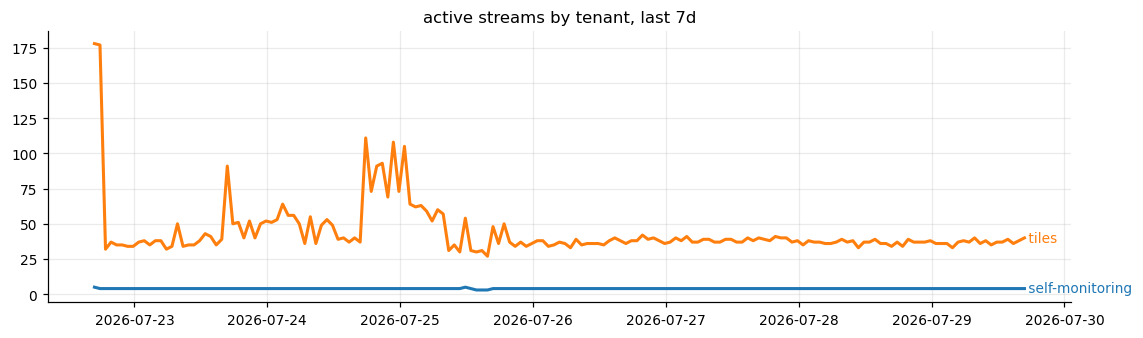

In [5]:
# --- STREAMS per tenant (churn = created - removed; high churn drives cardinality) ---
st = pd.DataFrame({'active_streams': pd.Series(streams_by_tenant),
                   'created_per_s': pd.Series(streams_created),
                   'removed_per_s': pd.Series(streams_removed)})
delta = (f_streams.iloc[-1] - f_streams.iloc[0]).rename('window_delta') if not f_streams.empty else pd.Series(dtype=float)
st = st.join(delta)
print(f"active streams total: {sum(streams_by_tenant.values()):,.0f}")
print(st.sort_values('active_streams', ascending=False).to_string(float_format=lambda v: f'{v:,.3f}', na_rep='-'))

fig, ax = plt.subplots(figsize=(12, 3.2))
for user in f_streams.columns:
    ax.plot(f_streams.index, f_streams[user], color=tenant_color(user), lw=2)
    ax.annotate(f" {user}", (f_streams.index[-1], f_streams[user].iloc[-1]),
                color=tenant_color(user), va='center')
ax.set_title(f'active streams by tenant, last {lookback_days}d')
nbc.show(fig)

                 lines_per_s  kB_per_s
tiles                  42.10     25.80
self-monitoring         4.00      0.40
discarded log lines over 7d by reason (total, last-24h): {'too_far_behind': (789775, 0), 'rate_limited': (48461, 0), 'greater_than_max_sample_age': (9647, 0), 'line_too_long': (31, 0)}
  -> all in the past; nothing discarded in the last 24h


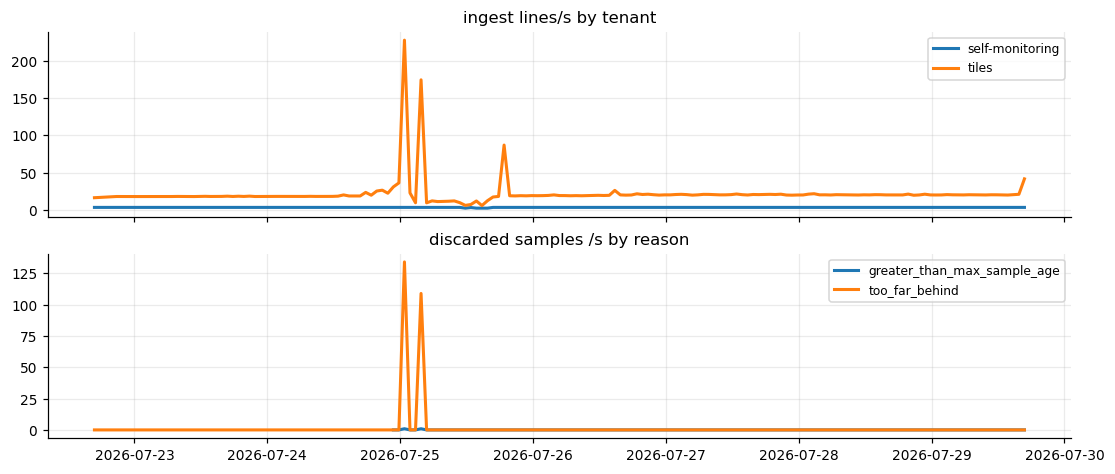

In [6]:
# --- INGEST per tenant: lines/s and bytes/s; discards by reason ---
ing = pd.DataFrame({'lines_per_s': pd.Series(lines_by_tenant),
                    'kB_per_s': pd.Series(bytes_by_tenant) / 1e3})
print(ing.sort_values('lines_per_s', ascending=False).to_string(float_format=lambda v: f'{v:,.2f}'))
f_discard_nz = f_discard.loc[:, f_discard.max() > 0] if not f_discard.empty else f_discard
disc_window_nz = {r: int(n) for r, n in sorted(disc_window.items(), key=lambda x: -x[1]) if n >= 1}
disc_recent_nz = {r: int(n) for r, n in disc_recent.items() if n >= 1}
print(f"discarded log lines over {lookback_days}d by reason (total, last-24h): "
      f"{ {r: (n, disc_recent_nz.get(r, 0)) for r, n in disc_window_nz.items()} or 'none'}")
if disc_window_nz and not disc_recent_nz:
    print("  -> all in the past; nothing discarded in the last 24h")

fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), sharex=True)
for user in f_lines.columns:
    axes[0].plot(f_lines.index, f_lines[user], color=tenant_color(user), lw=2, label=user)
axes[0].legend(fontsize=8)
axes[0].set_title('ingest lines/s by tenant')
if f_discard_nz.empty:
    axes[1].text(0.5, 0.5, 'no discarded samples in window', ha='center', va='center',
                 transform=axes[1].transAxes, color='0.4')
    axes[1].grid(False)
else:
    for c in f_discard_nz.columns:
        axes[1].plot(f_discard_nz.index, f_discard_nz[c], lw=2, label=c)
    axes[1].legend(fontsize=8)
axes[1].set_title('discarded samples /s by reason')
nbc.show(fig)

chunk age at flush:     p50 150.0 min, p99 238.2 min (target: chunks fill to max_chunk_age ~2h or size cap before flush)
chunk size at flush:    p50 234 KiB
chunk entries at flush: p50 9,600
chunks flushed: 0.011/s mean


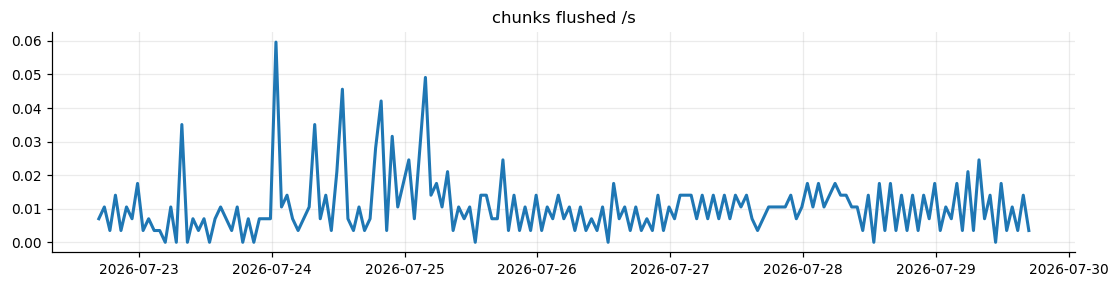

In [7]:
# --- CHUNK-FLUSH HEALTH: chunks flushed young/small waste object storage & query IO ---
print(f"chunk age at flush:     p50 {chunk_age_p50 / 60:,.1f} min, p99 {chunk_age_p99 / 60:,.1f} min "
      f"(target: chunks fill to max_chunk_age ~2h or size cap before flush)")
print(f"chunk size at flush:    p50 {chunk_size_p50 / 1024:,.0f} KiB")
print(f"chunk entries at flush: p50 {chunk_entries_p50:,.0f}")
cf = f_chunks_flushed['value'] if not f_chunks_flushed.empty else pd.Series(dtype=float)
print(f"chunks flushed: {cf.mean():,.3f}/s mean")

fig, ax = plt.subplots(figsize=(12, 2.6))
ax.plot(cf.index, cf, color='C0', lw=2)
ax.set_title('chunks flushed /s')
nbc.show(fig)

mean requests/s by read route (top 5):
loki_api_v1_query_range   2.130
loki_api_v1_query         0.153
loki_api_v1_labels        0.014
query p99 latency: max 0.16s (mixin LokiRequestLatency alerts >1s for 15m)
bytes scanned: 137.3 MB/s mean


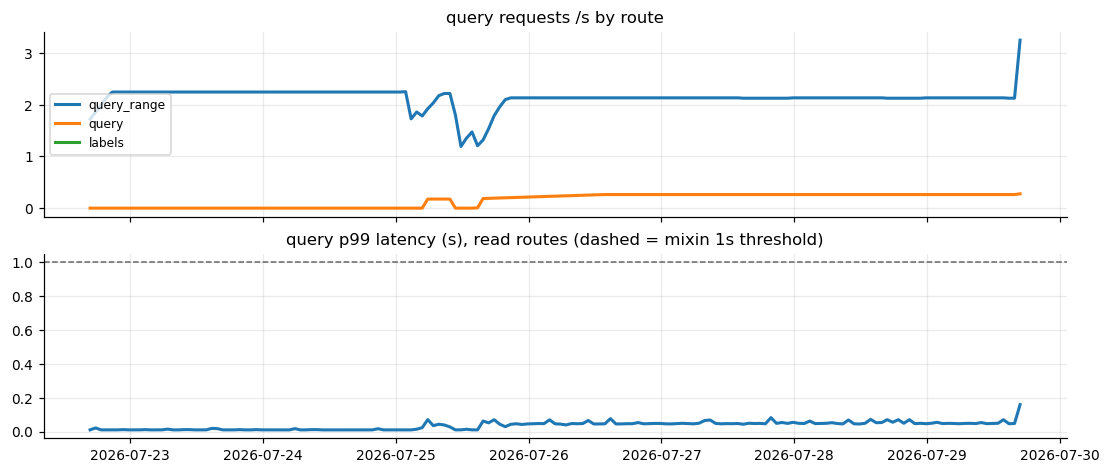

In [8]:
# --- QUERY LOAD: request rate by read route, p99 latency, bytes scanned ---
if not f_qrate.empty:
    qrate_top = f_qrate.loc[:, f_qrate.mean().sort_values(ascending=False).head(5).index]
    print("mean requests/s by read route (top 5):")
    print(qrate_top.mean().to_string(float_format=lambda v: f'{v:.3f}'))
else:
    qrate_top = f_qrate
    print("no query traffic in window")
p99 = f_qp99['value'] if not f_qp99.empty else pd.Series(dtype=float)
scan = f_scan['value'] if not f_scan.empty else pd.Series(dtype=float)
if p99.notna().any():
    print(f"query p99 latency: max {p99.max():.2f}s (mixin LokiRequestLatency alerts >1s for 15m)")
if scan.notna().any():
    print(f"bytes scanned: {scan.mean() / 1e6:,.1f} MB/s mean")

fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), sharex=True)
for c in qrate_top.columns:
    axes[0].plot(qrate_top.index, qrate_top[c], lw=2, label=c.replace('loki_api_v1_', ''))
if qrate_top.columns.size:
    axes[0].legend(fontsize=8)
axes[0].set_title('query requests /s by route')
if p99.notna().any():
    axes[1].plot(p99.index, p99, color='C0', lw=2)
    axes[1].axhline(1, color='0.4', ls='--', lw=1)
else:
    axes[1].text(0.5, 0.5, 'no query traffic in window', ha='center', va='center',
                 transform=axes[1].transAxes, color='0.4')
    axes[1].grid(False)
axes[1].set_title('query p99 latency (s), read routes (dashed = mixin 1s threshold)')
nbc.show(fig)

In [9]:
# --- SUMMARY: findings vs explicit thresholds ---
findings = []
if disc_recent_nz:
    findings.append(f"actively discarding log lines (last 24h): {disc_recent_nz} -- dropped data")
elif disc_window_nz:
    findings.append(f"discarded log lines earlier in the {lookback_days}d window (none in last 24h, "
                    f"so historical not ongoing): {disc_window_nz}")
if p99.notna().any() and p99.max() > 1:
    findings.append(f"query p99 latency exceeded 1s (max {p99.max():.2f}s; mixin LokiRequestLatency)")
if not np.isnan(chunk_age_p50) and chunk_age_p50 < 300 and (f_chunks_flushed['value'].mean() if not f_chunks_flushed.empty else 0) > 0:
    findings.append(f"chunks flushing young (p50 {chunk_age_p50 / 60:.1f} min <5 min) -- undersized chunks, check idle/max_chunk_age")

print("=" * 60)
print("LOKI USAGE SUMMARY")
print("=" * 60)
print(f"run:      {cap.run_at}  ({cap.mode})")
print(f"loki:     {loki_version}, window {lookback_days}d")
print()
if findings:
    print("Findings:")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- no limit discards, query latency within threshold, chunks sized reasonably")
print()
print(f"  Streams:  { {u: int(v) for u, v in sorted(streams_by_tenant.items())} } active")
print(f"  Ingest:   { {u: f'{v:,.1f}/s' for u, v in sorted(lines_by_tenant.items())} } lines")
print(f"  Discards: {lookback_days}d total {disc_window_nz or 'none'}; last-24h {disc_recent_nz or 'none'}")
print(f"  Queries:  {qrate_top.mean().sum():.3f} req/s mean; p99 {p99.max() if p99.notna().any() else float('nan'):.2f}s")

LOKI USAGE SUMMARY
run:      2026-07-29T16:46:42.007698+00:00  (live)
loki:     3.6.3, window 7d

Findings:
  ! discarded log lines earlier in the 7d window (none in last 24h, so historical not ongoing): {'too_far_behind': 789775, 'rate_limited': 48461, 'greater_than_max_sample_age': 9647, 'line_too_long': 31}

  Streams:  {'self-monitoring': 4, 'tiles': 40} active
  Ingest:   {'self-monitoring': '4.0/s', 'tiles': '42.1/s'} lines
  Discards: 7d total {'too_far_behind': 789775, 'rate_limited': 48461, 'greater_than_max_sample_age': 9647, 'line_too_long': 31}; last-24h none
  Queries:  2.297 req/s mean; p99 0.16s


In [10]:
# AGENT-READABLE STATS -- consolidated JSON for programmatic consumption.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb',
    'run_at': cap.run_at,
    'mode': cap.mode,
    'loki_version': loki_version,
    'lookback_days': lookback_days,
    'findings': findings,
    'streams': {
        'active_by_tenant': {u: _n(v) for u, v in streams_by_tenant.items()},
        'created_per_s_by_tenant': {u: _n(v) for u, v in streams_created.items()},
        'removed_per_s_by_tenant': {u: _n(v) for u, v in streams_removed.items()},
        'window_delta_by_tenant': {u: _n(v) for u, v in delta.items()},
    },
    'ingest': {
        'lines_per_s_by_tenant': {u: _n(v) for u, v in lines_by_tenant.items()},
        'bytes_per_s_by_tenant': {u: _n(v) for u, v in bytes_by_tenant.items()},
        'discarded_lines_window_total_by_reason': disc_window_nz,
        'discarded_lines_last24h_by_reason': disc_recent_nz,
    },
    'chunks': {
        'age_seconds': {'p50': _n(chunk_age_p50), 'p99': _n(chunk_age_p99)},
        'size_bytes_p50': _n(chunk_size_p50), 'entries_p50': _n(chunk_entries_p50),
        'flushed_per_s_mean': _n(f_chunks_flushed['value'].mean()) if not f_chunks_flushed.empty else None,
    },
    'queries': {
        'rate_per_s_mean_by_route': {c: _n(qrate_top[c].mean()) for c in qrate_top.columns},
        'p99_s_max': _n(p99.max()) if p99.notna().any() else None,
        'bytes_scanned_per_s_mean': _n(scan.mean()) if scan.notna().any() else None,
    },
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "loki-usage.ipynb",
 "run_at": "2026-07-29T16:46:42.007698+00:00",
 "mode": "live",
 "loki_version": "3.6.3",
 "lookback_days": 7,
 "findings": [
  "discarded log lines earlier in the 7d window (none in last 24h, so historical not ongoing): {'too_far_behind': 789775, 'rate_limited': 48461, 'greater_than_max_sample_age': 9647, 'line_too_long': 31}"
 ],
 "streams": {
  "active_by_tenant": {
   "self-monitoring": 4.0,
   "tiles": 40.0
  },
  "created_per_s_by_tenant": {
   "self-monitoring": 0.0,
   "tiles": 0.0017
  },
  "removed_per_s_by_tenant": {
   "self-monitoring": 0.0,
   "tiles": 0.0017
  },
  "window_delta_by_tenant": {
   "self-monitoring": -1.0,
   "tiles": -138.0
  }
 },
 "ingest": {
  "lines_per_s_by_tenant": {
   "self-monitoring": 4.0,
   "tiles": 42.1018
  },
  "bytes_per_s_by_tenant": {
   "self-monitoring": 400.0,
   "tiles": 25801.8807
  },
  "discarded_lines_window_total_by_reason": {
   "too_far_behind": 789775,
   "rate_limited": 48461,
   "greater_th